Predicted age of new abalone data point:11
Optimal value of k: 4
Minimum MSE: 8.135566188197767


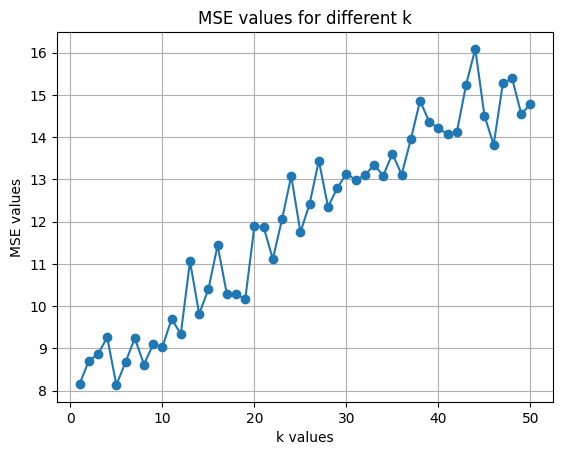

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
abalone = pd.read_csv(url, header=None)

column_names =  ["Sex", "Length", "Diameter", "Height", "Whole weight",
"Shucked weight", "Viscera weight", "Shell weight", "Rings"]
abalone.columns = column_names
abalone.drop(columns=["Sex"], inplace=True)
from sklearn.model_selection import train_test_split

X = abalone.drop(columns=["Rings"]).values
y = abalone["Rings"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=333)

new_abalone = np.array([0.569552, 0.446407, 0.154437, 1.016849, 0.439051, 0.222526, 0.291208])

def euclidean_distance(x,y):
   return np.linalg.norm(x - y,axis=1)

distances = euclidean_distance(X_train,new_abalone)
nearest_neighbors_indices = distances.argsort()[:3]

nearest_neighbors_ages = y_train[nearest_neighbors_indices]
mode_age = np.argmax(np.bincount(nearest_neighbors_ages))

print(f"Predicted age of new abalone data point:{mode_age}")


def k_nearest_neighbours(X_train, y_train, X_test, k=3):

    predicted_ages_test = []

    for data_point in X_test:
        distances = np.linalg.norm(X_train - data_point, axis=1)

        nearest_neighbors_indices = distances.argsort()[:k]

        nearest_neighbors_ages = y_train[nearest_neighbors_indices]

        mode_age = np.random.choice(np.unique(nearest_neighbors_ages), 1)[0]

        predicted_ages_test.append(mode_age)

    return np.array(predicted_ages_test)
mse_values = []

for k in range(1, 51):

    predicted_ages_test = k_nearest_neighbours(X_train, y_train, X_test, k)
    mse = np.mean((predicted_ages_test - y_test) ** 2)
    mse_values.append(mse)

optimal_k = np.argmin(mse_values)
min_mse = np.min(mse_values)

print("Optimal value of k:", optimal_k)
print("Minimum MSE:", min_mse)

plt.plot(range(1, 51), mse_values, marker='o', linestyle='-')
plt.xlabel('k values')
plt.ylabel('MSE values')
plt.title('MSE values for different k')
plt.grid(True)
plt.show()